## 1. Gemini Vision API com Python

Nesta célula, configuramos o ambiente, importamos as bibliotecas necessárias e autenticamos na API do Google Generative AI usando sua chave de API.

In [1]:
import os
import google.generativeai as genai
from PIL import Image
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pathlib import Path
import typing_extensions as typing
import json

load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")
if not api_key:
    print("[ERRO] GOOGLE_API_KEY não encontrada")
else:
    genai.configure(api_key=api_key)
    print("[OK] Conectado ao Google Generative AI")

c:\Users\ivanu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ivanu\AppData\Local\Temp\ipykernel_11864\2629518479.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


[OK] Conectado ao Google Generative AI


## 2. Localizando e Listando as Imagens

Aqui definimos o caminho do diretório e listamos todos os arquivos de imagem disponíveis para análise.

In [2]:
IMAGE_DIR = Path(r"C:\Users\ivanu\Desktop\recog_system\imagens")

if IMAGE_DIR.exists():
    images = sorted([f for f in IMAGE_DIR.iterdir() if f.suffix.lower() in [".jpg", ".png", ".jpeg"]])
    print(f"[INFO] Encontradas {{len(images)}} imagens em: {{IMAGE_DIR}}")
    for i, img_path in enumerate(images):
        print(f"{{i}}: {{img_path.name}}")
else:
    print(f"[ERRO] Diretorio {{IMAGE_DIR}} nao encontrado.")

[INFO] Encontradas {len(images)} imagens em: {IMAGE_DIR}
{i}: {img_path.name}
{i}: {img_path.name}
{i}: {img_path.name}
{i}: {img_path.name}


## 3. Carregar e Exibir a Imagem Selecionada

Carregamos a imagem escolhida para a memória e a visualizamos para confirmar se é o arquivo correto.

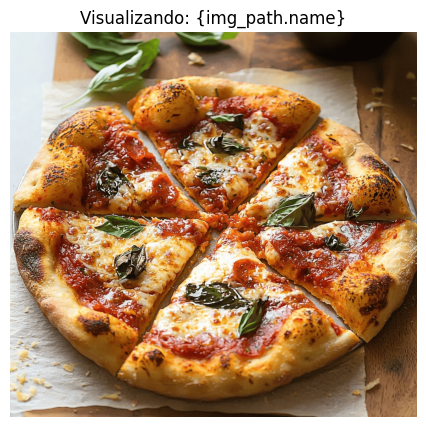

In [3]:
indice =3   # Pizza.png

if 'images' in locals() and indice < len(images):
    img_path = images[indice]
    img = Image.open(img_path)
    
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title(f"Visualizando: {{img_path.name}}")
    plt.axis("off")
    plt.show()
else:
    print("[ERRO] Imagem não encontrada.")

## 4. Inicialização do Modelo e Descrição Detalhada

Nesta etapa inicializamos o modelo `gemini-1.5-flash` para gerar uma descrição textual detalhada da imagem, focando em elementos principais e no contexto.

In [4]:
if 'img' in locals():
    model = genai.GenerativeModel('gemini-2.5-flash')
    prompt = "Descreva a imagem em detalhes, focando nos elementos principais, cores e no contexto geral."
    
    print("[INFO] Gerando descrição detalhada...")
    response = model.generate_content([prompt, img])
    
    print("\n--- Descrição da Imagem ---")
    print(response.text)
else:
    print("[ERRO] Carregue a imagem primeiro.")

[INFO] Gerando descrição detalhada...

--- Descrição da Imagem ---
A imagem apresenta uma apetitosa pizza recém-assada, cortada em seis fatias triangulares, disposta sobre um fundo rústico.

**Elementos Principais:**

1.  **A Pizza:**
    *   **Massa e Borda:** A massa da pizza possui uma borda (cornicione) bem desenvolvida e aerada, com uma coloração dourada intensa. Há pontos mais escuros e ligeiramente chamuscados em algumas partes da borda, indicando um cozimento em alta temperatura e conferindo um aspecto artesanal e crocante. A textura parece macia por dentro e crocante por fora.
    *   **Molho:** O molho de tomate é vibrante, de um vermelho intenso e brilhante. Parece ter uma consistência mais rústica, com pequenos pedaços de tomate, espalhado generosamente sobre a massa.
    *   **Queijo:** O queijo mozzarella está derretido e borbulhante, cobrindo o molho. Sua cor é um branco cremoso com tons amarelados em algumas áreas onde foi mais aquecido, criando um brilho convidativo. H

## 5. Geração de Output Estruturado (JSON)

Após a descrição livre, usamos o recurso de output estruturado do Gemini para extrair dados específicos em formato JSON seguindo um esquema rígido.

In [5]:
if 'img' in locals():
    class AnaliseImagem(typing.TypedDict):
        categoria: str
        objetos_detectados: list[str]
        descricao_resumida: str
        confianca: float

    print("\n[INFO] Gerando output estruturado...")
    response_structured = model.generate_content(
        ["Extraia os dados da imagem em JSON.", img],
        generation_config=genai.GenerationConfig(
            response_mime_type="application/json",
            response_schema=AnaliseImagem
        )
    )
    
    dados = json.loads(response_structured.text)
    print("\n--- Dados Estruturados (JSON) ---")
    print(json.dumps(dados, indent=2, ensure_ascii=False))
else:
    print("[ERRO] Carregue a imagem primeiro.")


[INFO] Gerando output estruturado...

--- Dados Estruturados (JSON) ---
{
  "categoria": "Pizza",
  "confianca": 0.98,
  "descricao_resumida": "Uma pizza Margherita recém-assada, cortada em fatias, com molho de tomate, queijo mussarela derretido e folhas de manjericão fresco por cima. A pizza está sobre um papel manteiga em uma superfície de madeira.",
  "objetos_detectados": [
    "pizza",
    "fatias de pizza",
    "queijo",
    "molho de tomate",
    "manjericão",
    "massa de pizza"
  ]
}
